In [3]:
import SciServer.CasJobs as CasJobs
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd

In [11]:

from astroquery.gaia import Gaia

query = """
SELECT source_id, ra, dec, parallax, 
       phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, ruwe
FROM gaiadr3.gaia_source
WHERE 1 = CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.85, 11.81, 0.5))
AND parallax_over_error > 10
AND phot_g_mean_mag < 18
"""
job = Gaia.launch_job(query)
df = job.get_results().to_pandas()

print(f"Success! Retrieved {len(df)} stars using Astroquery.")

Success! Retrieved 1703 stars using Astroquery.


In [12]:
import numpy as np

df = df[df['parallax'] > 0].copy()

df['dist'] = 1000 / df['parallax']

df['abs_mag_g'] = df['phot_g_mean_mag'] - 5 * np.log10(df['dist']) + 5
df['color'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
print("Success! Calculated values for", len(df), "stars.")
print(df[['source_id', 'dist', 'abs_mag_g', 'color']].head())

Success! Calculated values for 1703 stars.
            source_id        dist  abs_mag_g     color
0  598886361399495552  767.306467   8.108399  1.989975
1  598888285544863872  901.204950   5.987872  1.046636
2  598889419416217472  436.106100   7.382486  1.698810
3  598889900452561024  882.344763   5.640588  1.053546
4  598890037891519744  555.071570   6.075012  1.160821


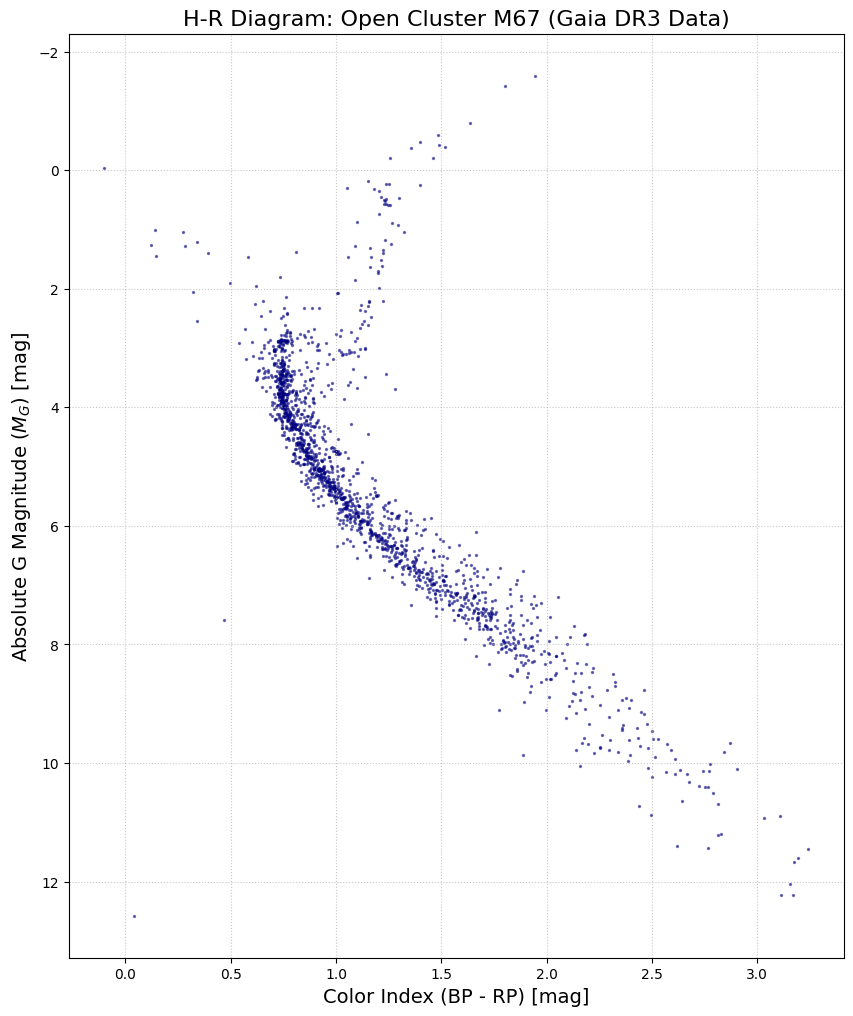

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 12))
plt.scatter(df['color'], df['abs_mag_g'], s=2, color='navy', alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel('Color Index (BP - RP) [mag]', fontsize=14)
plt.ylabel('Absolute G Magnitude ($M_G$) [mag]', fontsize=14)
plt.title('H-R Diagram: Open Cluster M67 (Gaia DR3 Data)', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()